# Performance

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
import pytz

## Data

In [10]:

performance_figures_out = '../../generated/figures/performance'
activity_csv_path = '../../generated/database/activity.csv'
coverage_csv_path = '../../generated/database/coverage.csv'

if not os.path.exists(activity_csv_path):
    raise FileNotFoundError(f"Le fichier {activity_csv_path} n'existe pas. Exécutez le notebook 'notebooks/arrange data/Database data.ipynb' pour le générer.")


df = pd.read_csv(activity_csv_path)

# Removing Outliers

df = df[df['user'] != '0947a22a-ec40-4f49-867b-330a623a1a35']

## Achievements overview

In [11]:
counts = df["achievement"].value_counts()
counts

achievement
Add1TestAchievement         11
Add10TestsAchievement        8
Cover10LinesAchievement      8
Kill1MutantAchievement       6
Kill5MutantsAchievement      6
Kill10MutantsAchievement     6
Cover33LinesAchievement      4
Add20TestsAchievement        4
Kill25MutantsAchievement     4
CleanDragonAchievement       2
Kill66MutantsAchievement     1
Name: count, dtype: int64

## Runs type

In [12]:
run_data = df.groupby(['game_mode', 'achievement']).size().reset_index(name='count')
run_data


,game_mode,achievement,count
0,SOLO,Add10TestsAchievement,6
1,SOLO,Add1TestAchievement,7
2,SOLO,Add20TestsAchievement,4
3,SOLO,Cover10LinesAchievement,5
4,SOLO,Cover33LinesAchievement,3
5,SOLO,Kill10MutantsAchievement,3
6,SOLO,Kill1MutantAchievement,3
7,SOLO,Kill25MutantsAchievement,2
8,SOLO,Kill5MutantsAchievement,3
9,SOLO,Kill66MutantsAchievement,1


# Nombre de tests par minute

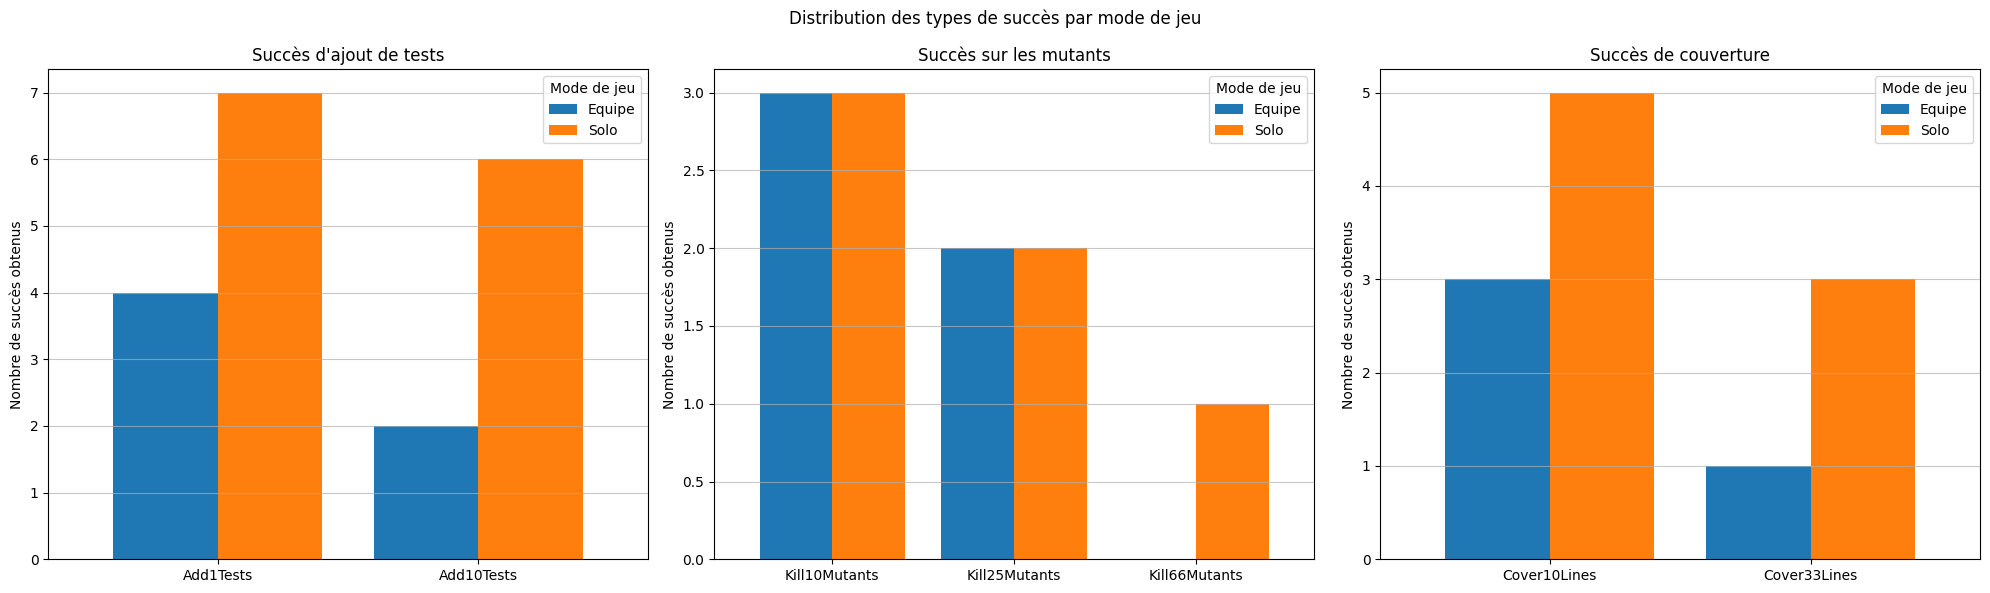

In [13]:
if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

# Créer une figure plus compacte et lisible 
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Add tests achievements
team_achievements = run_data[(run_data['game_mode'] == 'TEAM')]
solo_achievements = run_data[(run_data['game_mode'] == 'SOLO')]

data = pd.DataFrame({
    'Equipe': [
        team_achievements[team_achievements['achievement'] == 'Add1TestAchievement']['count'].values[0],
        team_achievements[team_achievements['achievement'] == 'Add10TestsAchievement']['count'].values[0]
    ],
    'Solo': [
        solo_achievements[solo_achievements['achievement'] == 'Add1TestAchievement']['count'].values[0],
        solo_achievements[solo_achievements['achievement'] == 'Add10TestsAchievement']['count'].values[0]
    ]
}, index=['Add1Tests', 'Add10Tests'])

data.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title("Succès d'ajout de tests")
ax1.set_ylabel("Nombre de succès obtenus")
ax1.legend(title="Mode de jeu")
ax1.grid(True, axis='y', alpha=0.7)
ax1.tick_params(axis='x', rotation=0)

# Mutants achievements

solo_10mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill10MutantsAchievement']['count'].values[0]
team_10mutants_achievement = \
    team_achievements[team_achievements['achievement'] == 'Kill10MutantsAchievement']['count'].values[0]
solo_25mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill25MutantsAchievement']['count'].values[0]
team_25mutants_achievement = \
    team_achievements[team_achievements['achievement'] == 'Kill25MutantsAchievement']['count'].values[0]
solo_66mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill66MutantsAchievement']['count'].values[0]


data2 = pd.DataFrame({
    'Equipe': [team_10mutants_achievement, team_25mutants_achievement, 0],
    'Solo': [solo_10mutants_achievement, solo_25mutants_achievement, solo_66mutants_achievement]
}, index=['Kill10Mutants', 'Kill25Mutants', "Kill66Mutants"])

data2.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title("Succès sur les mutants")
ax2.set_ylabel("Nombre de succès obtenus")
ax2.legend(title="Mode de jeu")
ax2.grid(True, axis='y', alpha=0.7)
ax2.tick_params(axis='x', rotation=0)

# Coverage Achievements

data = pd.DataFrame({
    'Equipe': [
        team_achievements[team_achievements['achievement'] == 'Cover10LinesAchievement']['count'].values[0],
        team_achievements[team_achievements['achievement'] == 'Cover33LinesAchievement']['count'].values[0]    ],
    'Solo': [
        solo_achievements[solo_achievements['achievement'] == 'Cover10LinesAchievement']['count'].values[0],
        solo_achievements[solo_achievements['achievement'] == 'Cover33LinesAchievement']['count'].values[0]    ]
}, index=['Cover10Lines', 'Cover33Lines'])
data.plot(kind='bar', ax=ax3, width=0.8)
ax3.set_title("Succès de couverture")
ax3.set_ylabel("Nombre de succès obtenus")
ax3.legend(title="Mode de jeu")
ax3.grid(True, axis='y', alpha=0.7)
ax3.tick_params(axis='x', rotation=0)

plt.suptitle("Distribution des types de succès par mode de jeu")
plt.tight_layout()
plt.savefig(f'{performance_figures_out}/runs_type_by_group_and_game_mode.pdf')
plt.show()

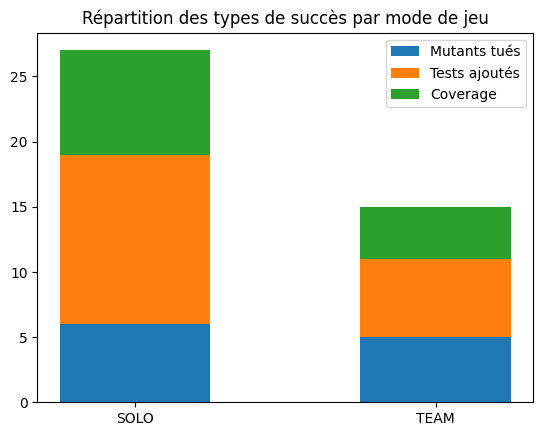

In [22]:
import matplotlib.pyplot as plt
import numpy as np

if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

# Add tests achievements
team_achievements = run_data[(run_data['game_mode'] == 'TEAM')]
solo_achievements = run_data[(run_data['game_mode'] == 'SOLO')]

team_tests =  team_achievements[team_achievements['achievement'] == 'Add1TestAchievement']['count'].values[0] + \
      team_achievements[team_achievements['achievement'] == 'Add10TestsAchievement']['count'].values[0]
solo_tests = solo_achievements[solo_achievements['achievement'] == 'Add1TestAchievement']['count'].values[0] + \
        solo_achievements[solo_achievements['achievement'] == 'Add10TestsAchievement']['count'].values[0]


# Mutants achievements

solo_10mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill10MutantsAchievement']['count'].values[0]
team_10mutants_achievement = \
    team_achievements[team_achievements['achievement'] == 'Kill10MutantsAchievement']['count'].values[0]
solo_25mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill25MutantsAchievement']['count'].values[0]
team_25mutants_achievement = \
    team_achievements[team_achievements['achievement'] == 'Kill25MutantsAchievement']['count'].values[0]
solo_66mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill66MutantsAchievement']['count'].values[0]


solo_mutants = solo_10mutants_achievement + solo_25mutants_achievement + solo_66mutants_achievement
team_mutants = team_10mutants_achievement + team_25mutants_achievement

# Coverage Achievements

team_coverage = team_achievements[team_achievements['achievement'] == 'Cover10LinesAchievement']['count'].values[0] + \
        team_achievements[team_achievements['achievement'] == 'Cover33LinesAchievement']['count'].values[0] 
solo_coverage = solo_achievements[solo_achievements['achievement'] == 'Cover10LinesAchievement']['count'].values[0] + \
        solo_achievements[solo_achievements['achievement'] == 'Cover33LinesAchievement']['count'].values[0]  


group = ("SOLO", "TEAM")

weight_count = {
    "Mutants tués": [solo_mutants, team_mutants],
    "Tests ajoutés": [solo_tests, team_tests],
    "Coverage": [solo_coverage, team_coverage]
}
width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(2)

for boolean, weight_count in weight_count.items():
    p = ax.bar(group, weight_count, width, label=boolean, bottom=bottom)
    bottom += weight_count

ax.set_title("Répartition des types de succès par mode de jeu")
ax.legend(loc="upper right")

plt.savefig(f'{performance_figures_out}/runs_type_by_group_and_game_mode2.pdf')
plt.show()

# Nombre de tests cumulé par minute

<Figure size 640x480 with 0 Axes>

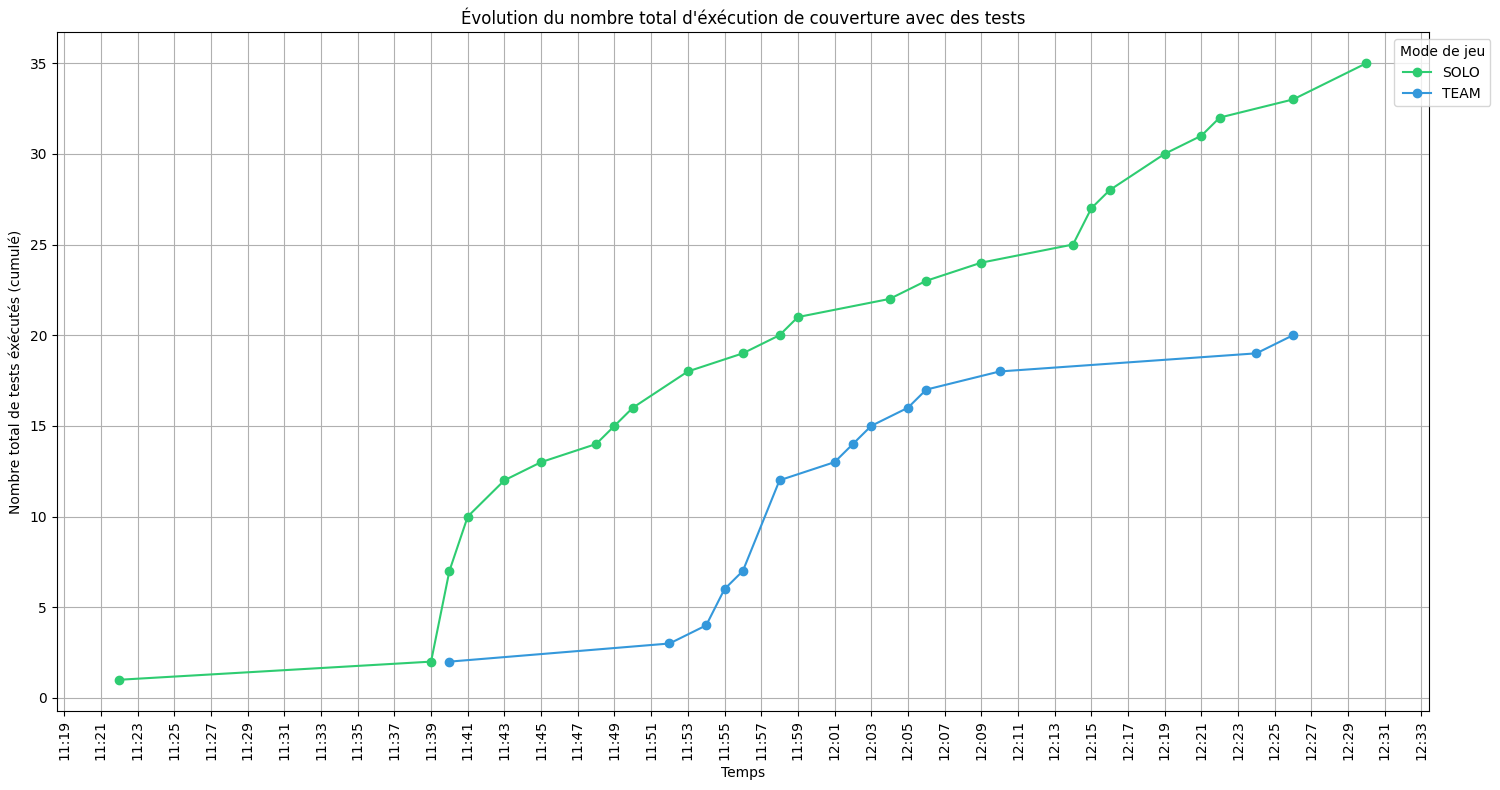

In [14]:
if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

df_coverage = pd.read_csv(coverage_csv_path)
df_coverage['created_at'] = pd.to_datetime(df_coverage['created_at'])
df_coverage['minute'] = df_coverage['created_at'].dt.floor('min')

team_coverage = df_coverage[df_coverage['game_mode'] == 'TEAM']
solo_coverage = df_coverage[df_coverage['game_mode'] == 'SOLO']

team_coverage['created_at'] = pd.to_datetime(team_coverage['created_at'])
solo_coverage['created_at'] = pd.to_datetime(solo_coverage['created_at'])

team_coverage['minute'] = team_coverage['created_at'].dt.floor('min')
solo_coverage['minute'] = solo_coverage['created_at'].dt.floor('min')

total_tests_per_minute = df_coverage.groupby(['minute', 'game_mode']).size().reset_index(name='count')
total_tests_per_minute = total_tests_per_minute.sort_values('minute')

plt.clf()  # Clear the current figure
fig, ax = plt.subplots(figsize=(15, 8))

# Define colors for different groups and modes
colors = {
    'SOLO': '#2ecc71',  # Vert émeraude
    'TEAM': '#3498db',  # Bleu clair
}

# Plot cumulative data first
for mode in ['SOLO', 'TEAM']:
    data = total_tests_per_minute[(total_tests_per_minute['game_mode'] == mode)]

    data = data.sort_values('minute')
    data['cumulative_count'] = data['count'].cumsum()

    line_color = colors[(mode)]
    plt.plot(data['minute'], data['cumulative_count'], label=f'{mode}', color=line_color, marker='o')


plt.title('Évolution du nombre total d\'éxécution de couverture avec des tests')
plt.xlabel('Temps')
plt.ylabel('Nombre total de tests éxécutés (cumulé)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=pytz.timezone('Europe/Brussels')))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
plt.xticks(rotation=90)

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Mode de jeu', bbox_to_anchor=(1.05, 1))

plt.grid(True)
plt.tight_layout()
plt.savefig(f'{performance_figures_out}/created_tests_count_cumsum.pdf')
plt.show()


<Figure size 1000x600 with 0 Axes>

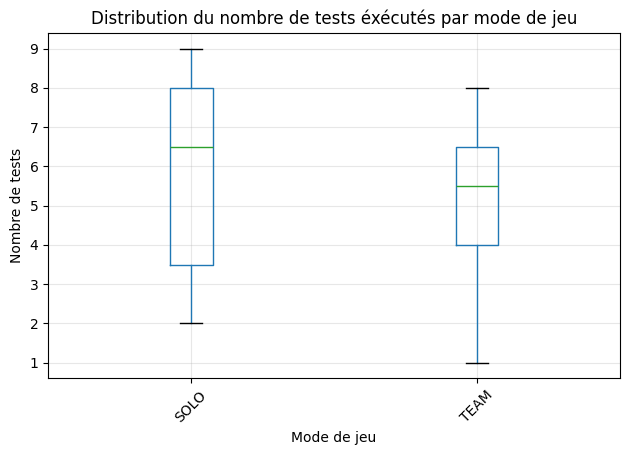

In [15]:
if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

# Création de la colonne count dans df_all_tests 
df_all_tests = df_coverage.groupby(['user', 'game_mode']).size().reset_index(
    name='count')

plt.figure(figsize=(10, 6))

# Create boxplot with groups split by game mode
boxplot = df_all_tests.boxplot(column='count', by=['game_mode'])

ax = plt.gca()
labels = [label.get_text().strip("(),'") for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)

plt.title('Distribution du nombre de tests éxécutés par mode de jeu')
plt.suptitle('')  # Remove automatic suptitle
plt.xlabel('Mode de jeu')
plt.ylabel('Nombre de tests')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

<Figure size 640x480 with 0 Axes>

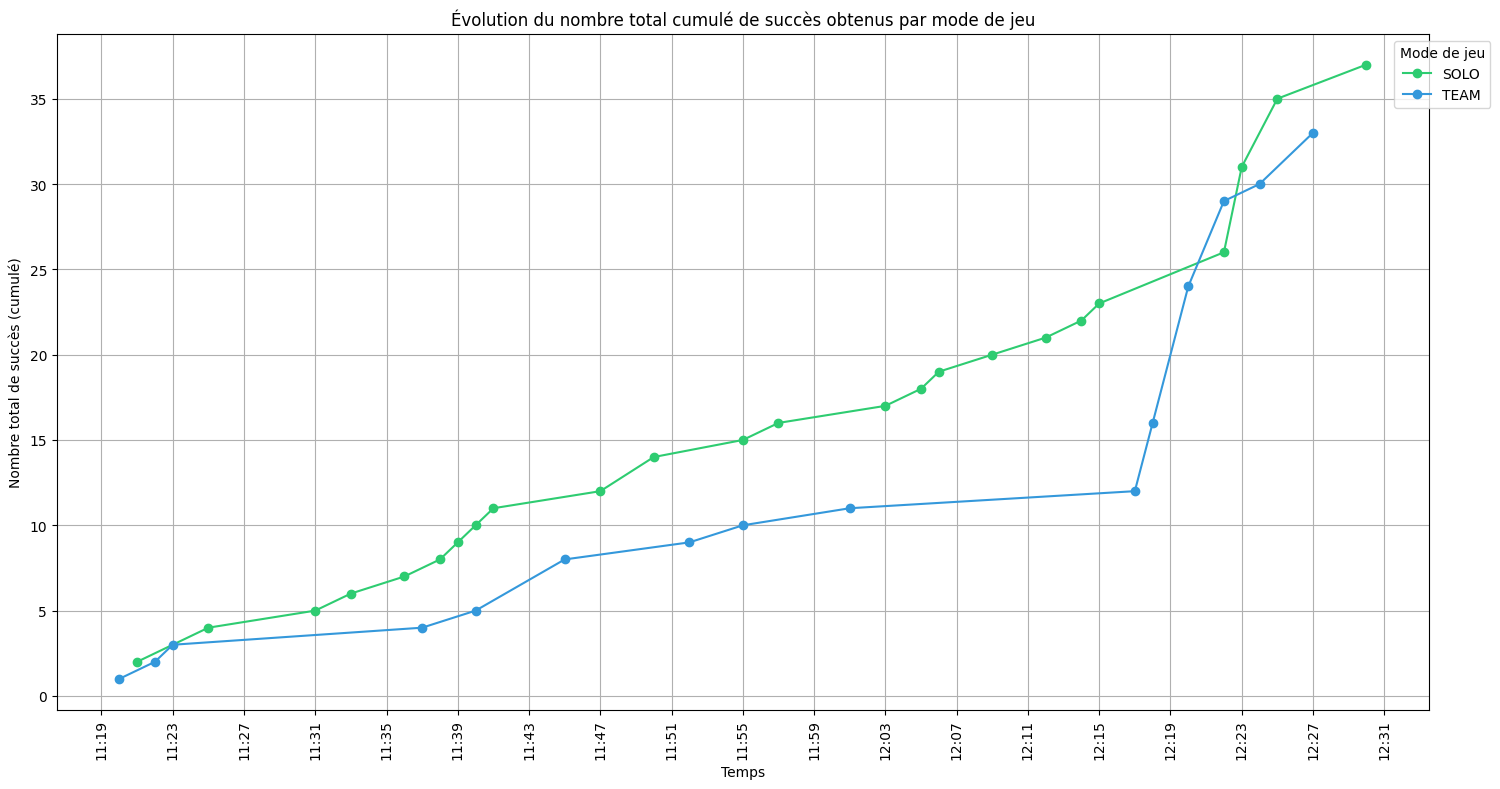

In [16]:
import pandas as pd
df_activity = pd.read_csv('../../generated/database/activity-brut.csv', sep = ',')
df_activity['timestamp'] = pd.to_datetime(df_activity['timestamp'], utc=False)

if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

df_all_tests = df_activity.copy()
df_all_tests['minute'] = df_all_tests['timestamp'].dt.floor('min')

total_tests_per_minute = df_all_tests.groupby(['minute', 'game_mode']).size().reset_index(name='count')
total_tests_per_minute = total_tests_per_minute.sort_values('minute')

plt.clf()  # Clear the current figure
fig, ax = plt.subplots(figsize=(15, 8))

# Define colors for different groups and modes
colors = {
    'SOLO': '#2ecc71',  # Vert émeraude
    'TEAM': '#3498db',  # Bleu clair
}

# Plot cumulative data first
for mode in ['SOLO', 'TEAM']:
    data = total_tests_per_minute[(total_tests_per_minute['game_mode'] == mode)]

    data = data.sort_values('minute')
    data['cumulative_count'] = data['count'].cumsum()

    line_color = colors[( mode)]
    plt.plot(data['minute'], data['cumulative_count'],
                label=f'{mode}',
                color=line_color,
                marker='o')


plt.title('Évolution du nombre total cumulé de succès obtenus par mode de jeu')
plt.xlabel('Temps')
plt.ylabel('Nombre total de succès (cumulé)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=pytz.timezone('Europe/Brussels')))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=4))
plt.xticks(rotation=90)

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),
           title='Mode de jeu',
           bbox_to_anchor=(1.05, 1))

plt.grid(True)
plt.tight_layout()
plt.savefig(f'{performance_figures_out}/actions_count_full_cumsum.pdf')
plt.show()
